# 01 — Exploratory Data Analysis

A thorough look at the Business Entity Resolution data: what each source looks like, how the ground truth is
structured, what kinds of noise separate true matches, what makes non-matches dangerous, how feasible blocking is,
and how the test set (with its unseen **France** slice) differs from train.

The verdict at the end summarises what this means for the pipeline.

**Conventions:** S1 = Source 1 (deduplicated reference), S2/S3 = sources to be matched against it.
Heavy per-row work runs on random samples; everything vectorisable runs on the full data.

## 0. Setup

In [1]:
%matplotlib inline
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from anyascii import anyascii
from rapidfuzz import fuzz, process

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})

# src/ sits next to this notebook (locally, and in the bundle notebooks/kaggle/push.py ships to Kaggle)
import sys
SRC = Path.cwd().resolve().parent / "src"
sys.path.insert(0, str(SRC))
from config import DATA_DIR as DATA, ON_KAGGLE
import sklearn, rapidfuzz, pyarrow
print(f"data: {DATA}  (on Kaggle: {ON_KAGGLE})")
print(f"python {sys.version.split()[0]}, pandas {pd.__version__}, numpy {np.__version__}, pyarrow {pyarrow.__version__}, "
      f"scikit-learn {sklearn.__version__}, rapidfuzz {rapidfuzz.__version__}")
SEED = 42
rng = np.random.default_rng(SEED)


def mem(label=""):
    """Peak resident memory of this kernel so far (Linux reports KB, macOS bytes)."""
    import resource, platform
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    gb = peak / 1e9 if platform.system() == "Darwin" else peak / 1e6
    print(f"[mem] peak {gb:.1f} GB {label}")


def take(obj, n, seed=SEED):
    """Random sample of up to n rows (never fails when fewer rows exist)."""
    return obj.sample(min(n, len(obj)), random_state=seed)

data: /kaggle/input/datasets/swapnilpramanik/ber-2026-challenge-data  (on Kaggle: True)
python 3.14.7, pandas 3.0.6, numpy 2.5.3, pyarrow 25.0.1, scikit-learn 1.9.1, rapidfuzz 3.14.6


In [2]:
def read_tsv(path):
    # keep_default_na=False: a business literally named "NA" must stay a string; only empty cells become null
    return pd.read_csv(path, sep="\t", engine="pyarrow", dtype_backend="pyarrow",
                       keep_default_na=False, na_values=[""])


def load_source(split, source):
    df = read_tsv(DATA / split / f"{split}_source{source}.tsv")
    df.columns = ["entity_id", "name", "address", "country"]
    df.insert(0, "split", split)
    df.insert(1, "source", f"S{source}")
    return df


t0 = time.time()
recs = pd.concat([load_source(sp, s) for sp in ("train", "test") for s in (1, 2, 3)], ignore_index=True)
for c in ("split", "source", "country"):
    recs[c] = recs[c].astype("category")
gt = read_tsv(DATA / "train" / "train_ground_truth.tsv")
gt.columns = ["s1", "matched"]
print(f"loaded {len(recs):,} records + {len(gt):,} ground-truth rows in {time.time() - t0:.1f}s, "
      f"{recs.memory_usage(deep=True).sum() / 1e9:.2f} GB")

loaded 24,229,173 records + 2,206,821 ground-truth rows in 26.3s, 2.58 GB


### Text normalisation used throughout

`normalize`: transliterate non-ASCII text to Latin (`anyascii`, applied only to rows that need it), lowercase,
replace every non-alphanumeric run with a space. This is a deliberately *simple* baseline normaliser — the point
of this notebook is to see how far it gets and where it breaks.

In [3]:
def normalize(s: pd.Series) -> pd.Series:
    s = s.fillna("")
    nonascii = s.str.contains(r"[^\x00-\x7F]")
    s = s.copy()
    s[nonascii] = [anyascii(x) for x in s[nonascii]]
    return s.str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()


t0 = time.time()
recs["name_n"] = normalize(recs["name"])
recs["addr_n"] = normalize(recs["address"])
print(f"normalised in {time.time() - t0:.1f}s")
recs[["source", "country", "name", "name_n", "address", "addr_n"]].pipe(take, 6, SEED)

normalised in 125.7s


,source,country,name,name_n,address,addr_n
18970890,S2,France,Commun & Frères SARL,commun freres sarl,"21 R. GÉNÉRAL LANRNZAC, NANTES",21 r general lanrnzac nantes
10257982,S3,India,Ankit Synthetics,ankit synthetics,"25-11-119, Guntur, ఆంధ్రప్రదేశ్",25 11 119 guntur amdhrprdes
22828045,S3,US,FDS Enterprises Holdings,fds enterprises holdings,"1403 Luscombe Drive, Toledo, Ohio",1403 luscombe drive toledo ohio
9142330,S3,US,Nius Cómpanies,nius companies,"1 Center Hill Rd, Monroe, New York",1 center hill rd monroe new york
13852130,S1,India,QBG Consultancy Pvt. Ltd.,qbg consultancy pvt ltd,"K.P.K House P.O Poyiloor North, Kannur, Kerala",k p k house p o poyiloor north kannur kerala
15237543,S2,US,CENTER THERAPY PHYSICAL,center therapy physical,"7754-7756 LYTLE STREET, SARAMENTO, CA",7754 7756 lytle street saramento ca


## 1. Source overview & integrity checks

In [4]:
g = recs.groupby(["split", "source"], observed=True)
overview = pd.DataFrame({
    "rows": g.size(),
    "unique_ids": g["entity_id"].nunique(),
    "id_prefix_ok": g.apply(lambda d: (d["entity_id"].str.slice(0, 2) == d.name[1]).mean(), include_groups=False),
    "empty_name": g["name"].apply(lambda s: s.isna().mean()),
    "empty_address": g["address"].apply(lambda s: s.isna().mean()),
    "blank_after_norm_name": g["name_n"].apply(lambda s: (s == "").mean()),
})
overview.style.format({"rows": "{:,}", "unique_ids": "{:,}", "id_prefix_ok": "{:.1%}", "empty_name": "{:.2%}",
                       "empty_address": "{:.2%}", "blank_after_norm_name": "{:.3%}"})

In [5]:
dupe_ids = recs["entity_id"].duplicated().sum()
exact_dupes = recs.duplicated(subset=["split", "source", "name", "address", "country"]).sum()
print(f"entity_ids repeated anywhere across all files: {dupe_ids:,}")
print(f"exact (name, address, country) duplicate rows within a split+source: {exact_dupes:,}")

entity_ids repeated anywhere across all files: 0
exact (name, address, country) duplicate rows within a split+source: 83,667


In [6]:
recs.groupby(["split", "source"], observed=True).sample(3, random_state=1)[
    ["split", "source", "entity_id", "name", "address", "country"]]

,split,source,entity_id,name,address,country
14232916,test,S1,S1-516069816,Collège Cathare,"20 Rue de Chateaudun, Tourcoing, Hauts-de-France",France
13080377,test,S1,S1-630580376,High Impex Private Limited,"Opp. Goyal House, Near Petrol Pump, Ajmer Road, Jaipur, Rajasthan",India
13317575,test,S1,S1-529868590,WFR Multitrade Private Limited,"8-B, F.Floor, Pkt-1, Sukhdev Vihar, New Delhi, South Delhi, Delhi",India
14565929,test,S2,S2-256124724,L.L.P. Indivar Communications,"F/12-D, HARI NAGAR, NEW DELHI, दिल्ली",India
14594842,test,S2,S2-233092649,Deleves & Fils SAS,<NA>,France
16054320,test,S2,S2-72550474,ONCOLOGY CARE (INC.),"CARTHAGE, TX, 710 SUNSET ST",US
21197088,test,S3,S3-784382825,Epsilon Private Aqua Limited,<NA>,India
20646344,test,S3,S3-445306410,Pharmacie Lage,"11 Rue Hoche, Calais, Hauts-de-France",France
23662721,test,S3,S3-118791845,Good Services Solutions Private Limited,"#46, Erode, தமிழ்நாடு",India
1745375,train,S1,S1-947161008,726-727 East Owners Corp,"1405 Michael Drive, Ankeny, IA",US


## 2. Country mix

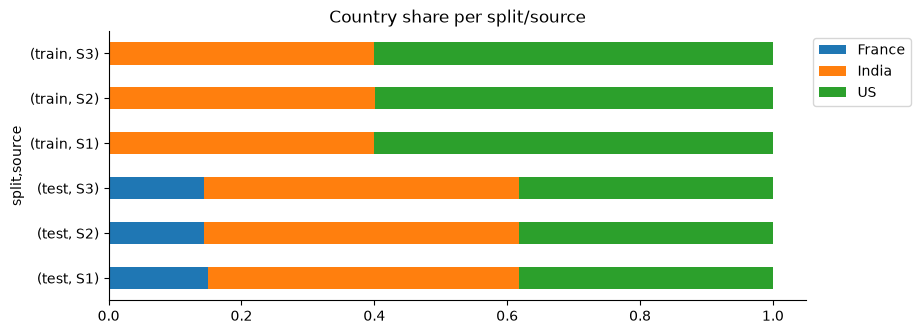

In [7]:
cmix = pd.crosstab([recs["split"], recs["source"]], recs["country"], normalize="index")
display(cmix.style.format("{:.1%}"))
cmix.plot.barh(stacked=True, figsize=(9, 3.5), title="Country share per split/source").legend(bbox_to_anchor=(1, 1))
plt.show()

In [8]:
# records in S2+S3 per S1 record, by country — a proxy for how many matches/distractors each entity has
counts = recs.groupby(["split", "country", "source"], observed=True).size().unstack("source")
counts["S2+S3 per S1"] = (counts["S2"] + counts["S3"]) / counts["S1"]
counts.style.format({"S1": "{:,}", "S2": "{:,}", "S3": "{:,}", "S2+S3 per S1": "{:.2f}"})

## 3. Missing fields and field shape

In [9]:
recs["no_addr"] = recs["address"].isna()
recs.pivot_table(index=["split", "source"], columns="country", values="no_addr", aggfunc="mean",
                 observed=True).style.format("{:.2%}")

In [10]:
recs["name_len"] = recs["name"].str.len()
recs["name_tokens"] = recs["name_n"].str.count(r"\S+")
recs["addr_len"] = recs["address"].str.len()
recs["addr_parts"] = recs["address"].str.count(",") + 1

shape = recs.groupby(["split", "source", "country"], observed=True)[
    ["name_len", "name_tokens", "addr_len", "addr_parts"]].median()
shape

name_len  name_tokens  addr_len  addr_parts
split source country                                             
test  S1     France       19.0          3.0      48.0         3.0
             India        27.0          4.0      76.0         6.0
             US           22.0          3.0      34.0         3.0
      S2     France       20.0          3.0      41.0         3.0
             India        28.0          4.0      69.0         5.0
             US           24.0          4.0      32.0         3.0
      S3     France       20.0          3.0      41.0         3.0
             India        28.0          4.0      59.0         4.0
             US           24.0          4.0      39.0         3.0
train S1     India        27.0          4.0      76.0         5.0
             US           22.0          3.0      34.0         3.0
      S2     India        27.0          4.0      69.0         5.0
             US           23.0          3.0      32.0         3.0
      S3     India        27.0          4.0      60.0         4.0
             US           23.0          3.0      39.0         3.0

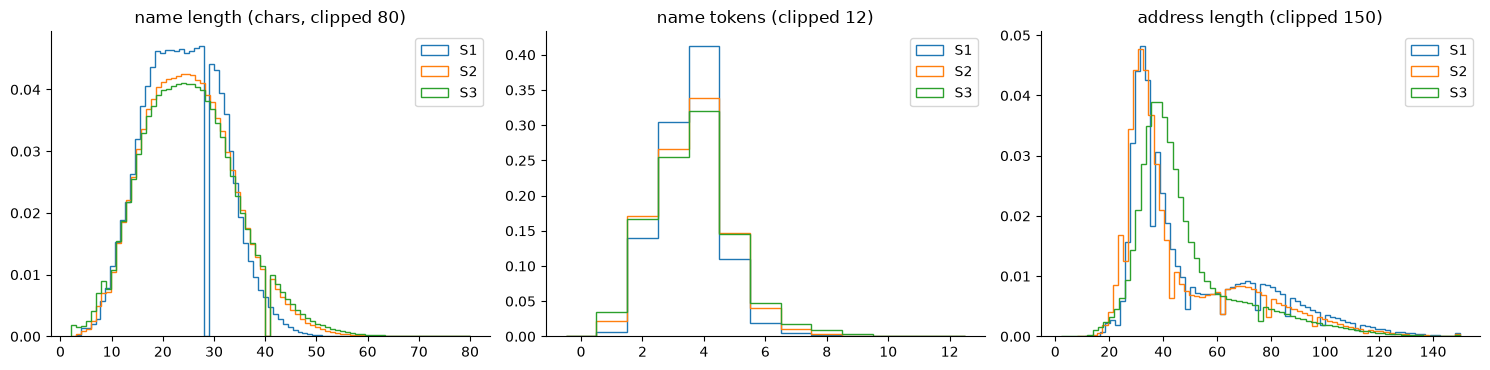

In [11]:
tr = recs.loc[recs["split"] == "train", ["source", "name_len", "name_tokens", "addr_len"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for src in ("S1", "S2", "S3"):
    d = tr[tr["source"] == src]
    axes[0].hist(d["name_len"].clip(upper=80), bins=80, histtype="step", density=True, label=src)
    axes[1].hist(d["name_tokens"].clip(upper=12), bins=np.arange(14) - 0.5, histtype="step", density=True, label=src)
    axes[2].hist(d["addr_len"].dropna().clip(upper=150), bins=75, histtype="step", density=True, label=src)
for ax, t in zip(axes, ["name length (chars, clipped 80)", "name tokens (clipped 12)", "address length (clipped 150)"]):
    ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()
del tr

In [12]:
# formatting style: ALL-CAPS and all-lowercase rates
def case_rates(col):
    s = recs[col].fillna("")
    has_alpha = s.str.contains(r"[A-Za-z]")
    return pd.DataFrame({
        f"{col}_upper": (has_alpha & (s == s.str.upper())),
        f"{col}_lower": (has_alpha & (s == s.str.lower())),
    })

cr = pd.concat([recs[["split", "source", "country"]], case_rates("name"), case_rates("address")], axis=1)
case_tbl = cr.groupby(["split", "source", "country"], observed=True).mean()
del cr
case_tbl.style.format("{:.1%}")

## 4. Scripts, transliteration and accents

In [13]:
# explicit Unicode block ranges (non-raw strings, so the pattern holds the literal characters):
# portable across Python's re and pyarrow's RE2, unlike \\p{Script} which only RE2 understands
SCRIPTS = {
    "Devanagari": "[\u0900-\u097F]", "Bengali": "[\u0980-\u09FF]", "Gurmukhi": "[\u0A00-\u0A7F]",
    "Gujarati": "[\u0A80-\u0AFF]", "Oriya": "[\u0B00-\u0B7F]", "Tamil": "[\u0B80-\u0BFF]",
    "Telugu": "[\u0C00-\u0C7F]", "Kannada": "[\u0C80-\u0CFF]", "Malayalam": "[\u0D00-\u0D7F]",
    "Arabic": "[\u0600-\u06FF]", "Latin accents": "[À-ÖØ-öø-ÿĀ-ž]",
}

rows = []
for col in ("name", "address"):
    s = recs[col].fillna("")
    na = s.str.contains(r"[^\x00-\x7F]")
    sub = recs.loc[na, ["split", "source", "country"]]
    for script, pat in SCRIPTS.items():
        hit = s[na].str.contains(pat)
        r = hit.groupby([sub["split"], sub["source"], sub["country"]], observed=True).sum()
        rows.append(r.rename(f"{col}:{script}"))
    rows.append(na.groupby([recs["split"], recs["source"], recs["country"]], observed=True).sum().rename(f"{col}:any non-ASCII"))

tot = recs.groupby(["split", "source", "country"], observed=True).size()
script_rates = pd.concat(rows, axis=1).fillna(0).div(tot, axis=0)
script_rates = script_rates.loc[:, script_rates.max() > 0.0005]
script_rates.style.format("{:.2%}").background_gradient(axis=None, cmap="Blues")

In [14]:
# what do non-Latin names/addresses look like, and what does transliteration give us?
india = recs.loc[(recs["country"] == "India") & (recs["split"] == "train"), ["source", "name", "name_n", "address", "addr_n"]]
ex = india[india["name"].str.contains(SCRIPTS["Devanagari"])].pipe(take, 8, 3)
display(ex[["source", "name", "name_n"]])
ex = india[india["address"].fillna("").str.contains("|".join(SCRIPTS[k] for k in ("Tamil", "Gujarati", "Bengali", "Telugu", "Kannada")))]
ex = ex.pipe(take, min(8, len(ex)), 3)
display(ex[["source", "address", "addr_n"]])

,source,name,name_n
4060233,S2,मॉडर्न कंसल्टिंग एलएलपी,modrn kmsltimg elelpi
9828238,S3,विजन ग्लोबल प्राइवेट लिमिटेड,vijn globl praivet limited
5839119,S2,सिटी ट्रेडिंग प्राइवेट लिमिटेड,siti tredimg praivet limited
8061694,S3,व्हाइट सॉफ्टवेयर,vhait sophtveyr
5278671,S2,परफेक्ट ब्राइट कंसल्टेंट्स प्रा. लि.,prphekt brait kmsltemts pra li
5878939,S2,होटल ग्रीन इम्पेक्स प्राइवेट लिमिटेड,hotl grin impeks praivet limited
6600868,S2,हाईटेक इन्वेस्टमेंट्स,haitek investmemts
6800496,S2,स्मार्ट आईटी प्राइवेट लिमिटेड,smart aiti praivet limited


,source,address,addr_n
5364603,S2,"C/O. DILIPBHAI CHANDRAKANTBHAI PANDHI SHILP TOWER OFF NO 40, GODWN ROAD, RAJKOT, ગુજરાત",c o dilipbhai chandrakantbhai pandhi shilp tower off no 40 godwn road rajkot gujrat
11757963,S3,"01, Patharghata, North 24 Parganas, পশ্চিমবঙ্গ",01 patharghata north 24 parganas pscimbng
11621533,S3,"Plot 606 Bld.no-b.4 Flat No-902, Vraj Raj Residency, Surat, Surat City, ગુજરાત",plot 606 bld no b 4 flat no 902 vraj raj residency surat surat city gujrat
7894792,S3,"No.72/153, Venkatarangan Pillai Street Triplicane, Chennai, தமிழ்நாடு",no 72 153 venkatarangan pillai street triplicane chennai tmilnatu
7905778,S3,"New No. #791 (Old No.427) Poonamallee High Road Arumbakkam, Chennai, Tiruvallur, தமிழ்நாடு",new no 791 old no 427 poonamallee high road arumbakkam chennai tiruvallur tmilnatu
8869481,S3,"B4, Bangalore, ಕರ್ನಾಟಕ",b4 bangalore krnatk
7333613,S3,"Flat No. D, 1St Floor, Block No C, 202 Jessore Road, Shyam Lake Garden, Lake Town, North 24 Pgs, North 24 ...",flat no d 1st floor block no c 202 jessore road shyam lake garden lake town north 24 pgs north 24 parganas...
8632276,S3,"#93. Maynaguri P. O. - Maynaguri, Maynaguri, P. S. - Maynaguri, পশ্চিমবঙ্গ",93 maynaguri p o maynaguri maynaguri p s maynaguri pscimbng


In [15]:
# where do the local-script fragments sit inside addresses? (mostly the state name?)
loc = india["address"].fillna("")
parts = loc[loc.str.contains(r"[^\x00-\x7F]")].str.split(",").explode().str.strip()
nonlatin_parts = parts[parts.str.contains(r"[^\x00-\x7F]")]
nonlatin_parts.value_counts().head(25).to_frame("count").assign(transliterated=lambda d: [anyascii(x) for x in d.index])

,count,transliterated
address,,
महाराष्ट्र,212813,mharastr
दिल्ली,133870,dilli
उत्तर प्रदेश,81729,uttr prdes
ಕರ್ನಾಟಕ,77534,krnatk
தமிழ்நாடு,69755,tmilnatu
পশ্চিমবঙ্গ,63218,pscimbng
ગુજરાત,63060,gujrat
తెలంగాణ,49836,telmgan
हरियाणा,39334,hriyana


## 5. Ground truth structure

In [16]:
gt["matched"] = gt["matched"].fillna("")
gt["n_matches"] = np.where(gt["matched"] == "", 0, gt["matched"].str.count(",") + 1)
pairs = (gt.assign(m=gt["matched"].str.split(",")).explode("m")[["s1", "m"]]
           .query("m != ''").reset_index(drop=True))
pairs["m_src"] = pairs["m"].str.slice(0, 2)

train_ids = {s: set(recs.loc[(recs["split"] == "train") & (recs["source"] == s), "entity_id"]) for s in ("S1", "S2", "S3")}
print(f"GT rows: {len(gt):,}   S1 train records: {len(train_ids['S1']):,}")
print(f"every S1 appears in GT exactly once: {set(gt['s1']) == train_ids['S1'] and not gt['s1'].duplicated().any()}")
print(f"positive pairs: {len(pairs):,}  (S2: {(pairs['m_src'] == 'S2').sum():,}, S3: {(pairs['m_src'] == 'S3').sum():,})")
print(f"all matched ids exist in S2/S3: {pairs['m'].isin(train_ids['S2'] | train_ids['S3']).all()}")
print(f"S2/S3 records matched to >1 S1: {pairs['m'].duplicated().sum():,}")
print(f"duplicate ids within a single match list: {pairs.duplicated(['s1', 'm']).sum():,}")

GT rows: 2,206,821   S1 train records: 2,206,821


every S1 appears in GT exactly once: True


positive pairs: 7,638,365  (S2: 3,693,619, S3: 3,944,746)


all matched ids exist in S2/S3: True


S2/S3 records matched to >1 S1: 0


duplicate ids within a single match list: 0


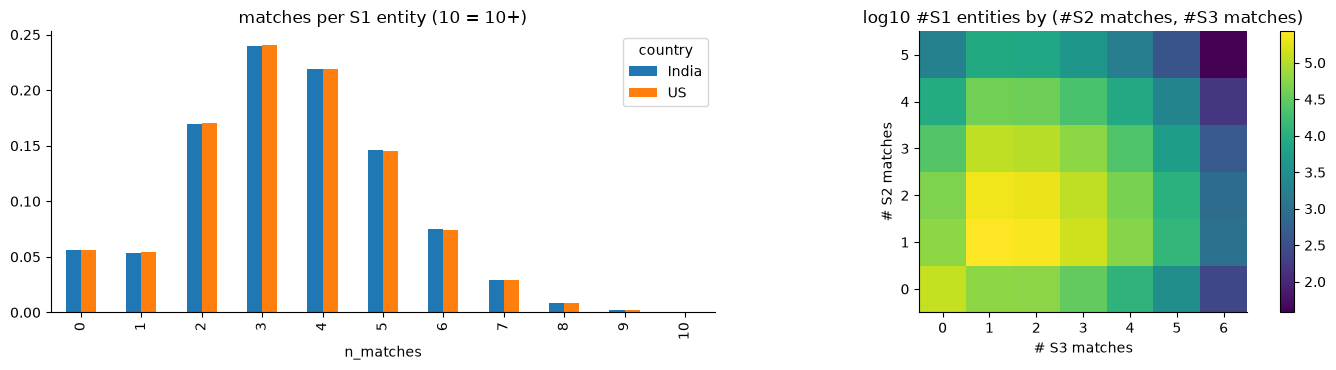

,entities,singleton_rate,mean_matches,median_matches,has_s2,has_s3,max_matches
country,,,,,,,
India,"883,188",5.6%,3.46,3.000000,87.0%,87.9%,11
US,"1,323,633",5.6%,3.46,3.000000,86.9%,87.9%,11


In [17]:
s1_country = recs.loc[(recs["split"] == "train") & (recs["source"] == "S1")].set_index("entity_id")["country"]
gt["country"] = gt["s1"].map(s1_country)
gt["n_s2"] = gt["matched"].str.count("S2-")
gt["n_s3"] = gt["matched"].str.count("S3-")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
dist = pd.crosstab(gt["n_matches"].clip(upper=10), gt["country"], normalize="columns")
dist.plot.bar(ax=axes[0], title="matches per S1 entity (10 = 10+)")
heat = np.log10(pd.crosstab(gt["n_s2"], gt["n_s3"]) + 1)
im = axes[1].imshow(heat.values, cmap="viridis", origin="lower"); fig.colorbar(im, ax=axes[1])
axes[1].set_title("log10 #S1 entities by (#S2 matches, #S3 matches)")
axes[1].set_xlabel("# S3 matches"); axes[1].set_ylabel("# S2 matches")
plt.tight_layout(); plt.show()

summary = gt.groupby("country", observed=True).agg(
    entities=("s1", "size"), singleton_rate=("n_matches", lambda s: (s == 0).mean()),
    mean_matches=("n_matches", "mean"), median_matches=("n_matches", "median"),
    has_s2=("n_s2", lambda s: (s > 0).mean()), has_s3=("n_s3", lambda s: (s > 0).mean()),
    max_matches=("n_matches", "max"))
summary.style.format({"entities": "{:,}", "singleton_rate": "{:.1%}", "mean_matches": "{:.2f}",
                      "has_s2": "{:.1%}", "has_s3": "{:.1%}"})

In [18]:
# how many S2/S3 records are distractors (never matched)?
matched_set = set(pairs["m"])
s23 = recs.loc[(recs["split"] == "train") & recs["source"].isin(["S2", "S3"]), ["entity_id", "source", "country", "no_addr", "name_n"]].copy()
s23["is_matched"] = s23["entity_id"].isin(matched_set)
display(s23.pivot_table(index="source", columns="country", values="is_matched", aggfunc="mean", observed=True)
           .style.format("{:.1%}").set_caption("share of S2/S3 records that match some S1"))
print("share of matched vs distractor records with an empty address:")
print(s23.groupby("is_matched")["no_addr"].mean().map("{:.2%}".format).to_string())

country,India,US
source,,
S2,73.4%,73.4%
S3,74.7%,74.6%


share of matched vs distractor records with an empty address:


is_matched
False    0.29%
True     4.41%


In [19]:
# per-source duplication: how often does a source hold *several* records for the same entity?
multi = pd.DataFrame({
    ">=2 S2 matches": (gt["n_s2"] >= 2).mean(),
    ">=2 S3 matches": (gt["n_s3"] >= 2).mean(),
    "S2 and S3 both": ((gt["n_s2"] > 0) & (gt["n_s3"] > 0)).mean(),
}, index=["share of S1 entities"]).T
multi.style.format("{:.1%}")

,share of S1 entities
>=2 S2 matches,51.2%
>=2 S3 matches,55.5%
S2 and S3 both,80.5%


## 6. True pairs — how similar are matches really?

In [20]:
# ownership map: every matched S2/S3 id -> its single S1 owner (§5 showed ownership is unique)
owner = pairs.set_index("m")["s1"]
train_mask = recs["split"] == "train"
country_of = recs.loc[train_mask, ["entity_id", "country"]].set_index("entity_id")["country"].astype(str)
agree = (pairs["s1"].map(country_of) == pairs["m"].map(country_of)).mean()
print(f"country agreement across ALL {len(pairs):,} true pairs: {agree:.4%}")
del country_of

# full string comparisons on a 1M-pair random sample (a full 7.6M-row join of four text columns is too heavy)
cols = ["entity_id", "name", "address", "country", "name_n", "addr_n"]
P = pairs.pipe(take, 1_000_000, SEED)
need = pd.Index(P["s1"]).append(pd.Index(P["m"]))
train_recs = recs.loc[train_mask & recs["entity_id"].isin(need), cols].set_index("entity_id")
P = P.join(train_recs, on="s1").join(train_recs, on="m", rsuffix="_m").reset_index(drop=True)
del train_recs, need
print(f"on a {len(P):,}-pair sample:")
print(f"identical raw name:            {(P['name'] == P['name_m']).mean():.1%}")
print(f"identical lowercased name:     {(P['name'].str.lower() == P['name_m'].str.lower()).mean():.1%}")
print(f"identical normalised name:     {(P['name_n'] == P['name_n_m']).mean():.1%}")
print(f"identical normalised address:  {(P['addr_n'] == P['addr_n_m']).mean():.1%}")
mem("after §6 pairs")

country agreement across ALL 7,638,365 true pairs: 100.0000%


on a 1,000,000-pair sample:
identical raw name:            4.7%
identical lowercased name:     10.8%
identical normalised name:     25.8%
identical normalised address:  8.3%
[mem] peak 15.9 GB after §6 pairs


**Negatives for comparison.** *Random* negatives: a random same-country S2/S3 record per sampled S1 entity.
*Hard* negatives: a random same-country S2/S3 record that shares the **first normalised name token** with the
S1 entity but is not one of its matches — roughly what a naive name block would surface.

In [21]:
N = 300_000
pos = P.pipe(take, N, SEED).reset_index(drop=True)
lean = ["entity_id", "country", "name_n", "addr_n"]
s1_tr = recs.loc[train_mask & (recs["source"] == "S1"), lean].reset_index(drop=True)
s23_tr = recs.loc[train_mask & recs["source"].isin(["S2", "S3"]), lean + ["source"]].reset_index(drop=True)


def drop_true_pairs(df):
    """Remove rows where entity_id_m is actually owned by entity_id."""
    owned_by = df["entity_id_m"].map(owner).fillna("")
    return df[(owned_by != df["entity_id"]).to_numpy(dtype=bool)]


# random negatives, same country
anchors = s1_tr.pipe(take, N, SEED + 1).reset_index(drop=True)
neg_parts = []
for ctry, a in anchors.groupby("country", observed=True):
    pool_idx = np.flatnonzero((s23_tr["country"] == ctry).to_numpy())
    pick = s23_tr.iloc[rng.choice(pool_idx, len(a))].reset_index(drop=True)
    neg_parts.append(pd.concat([a.reset_index(drop=True), pick.add_suffix("_m")], axis=1))
rneg = drop_true_pairs(pd.concat(neg_parts, ignore_index=True))

# hard negatives: share first name token, same country (two random records per (country, token) key)
s23_tr["tok0"] = s23_tr["name_n"].str.extract(r"^(?P<tok>\S*)")["tok"]
anchors["tok0"] = anchors["name_n"].str.extract(r"^(?P<tok>\S*)")["tok"]
pools = []
for k in range(2):
    order = np.random.default_rng(SEED + k).permutation(len(s23_tr))
    pools.append(s23_tr.iloc[order].drop_duplicates(["country", "tok0"], keep="first"))
pool = pd.concat(pools)
del pools
hneg = anchors.merge(pool.add_suffix("_m"), left_on=["country", "tok0"], right_on=["country_m", "tok0_m"])
hneg = drop_true_pairs(hneg).drop_duplicates("entity_id").pipe(take, N, SEED)
del pool
mem("after §6 negatives")
print(f"positives {len(pos):,}  random negatives {len(rneg):,}  hard negatives {len(hneg):,}")

[mem] peak 18.2 GB after §6 negatives
positives 300,000  random negatives 299,998  hard negatives 296,201


In [22]:
def score(df):
    a, b = df["name_n"].tolist(), df["name_n_m"].tolist()
    aa, ba = df["addr_n"].tolist(), df["addr_n_m"].tolist()
    out = pd.DataFrame({
        "name_ratio": process.cpdist(a, b, scorer=fuzz.ratio, workers=-1),
        "name_token_set": process.cpdist(a, b, scorer=fuzz.token_set_ratio, workers=-1),
        "name_token_sort": process.cpdist(a, b, scorer=fuzz.token_sort_ratio, workers=-1),
        "name_partial": process.cpdist(a, b, scorer=fuzz.partial_ratio, workers=-1),
        "addr_token_set": process.cpdist(aa, ba, scorer=fuzz.token_set_ratio, workers=-1),
    }, index=df.index)
    out.loc[(df["addr_n"] == "") | (df["addr_n_m"] == ""), "addr_token_set"] = np.nan
    out["country"] = df["country"].astype(str).values
    return out

S = pd.concat([score(pos).assign(label="positive"), score(rneg).assign(label="random neg"),
               score(hneg).assign(label="hard neg")], ignore_index=True)
feats = ["name_ratio", "name_token_set", "name_token_sort", "name_partial", "addr_token_set"]
S.groupby("label")[feats].quantile([0.05, 0.25, 0.5, 0.75]).unstack().round(0).T.unstack()

label           hard neg                   positive                     random neg                  
                    0.05  0.25  0.50  0.75     0.05  0.25   0.50   0.75       0.05  0.25  0.50  0.75
name_ratio          39.0  49.0  55.0  64.0     56.0  76.0   88.0  100.0       21.0  29.0  34.0  41.0
name_token_set      43.0  52.0  60.0  71.0     55.0  89.0  100.0  100.0       21.0  29.0  34.0  41.0
name_token_sort     34.0  44.0  52.0  60.0     50.0  77.0   90.0  100.0       21.0  29.0  34.0  40.0
name_partial        50.0  59.0  67.0  74.0     67.0  87.0  100.0  100.0       31.0  38.0  42.0  50.0
addr_token_set      28.0  33.0  37.0  42.0     73.0  88.0   94.0   99.0       27.0  33.0  37.0  41.0

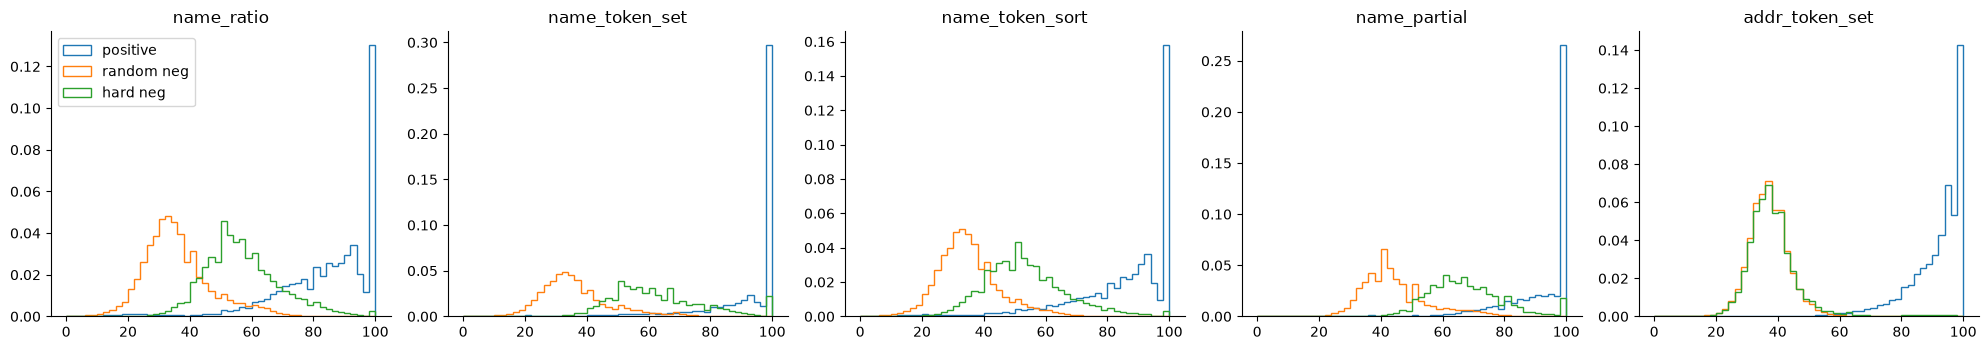

In [23]:
fig, axes = plt.subplots(1, len(feats), figsize=(20, 3.6), sharey=False)
for ax, f in zip(axes, feats):
    for lab in ("positive", "random neg", "hard neg"):
        ax.hist(S.loc[S["label"] == lab, f].dropna(), bins=50, range=(0, 100), histtype="step", density=True, label=lab)
    ax.set_title(f)
axes[0].legend()
plt.tight_layout(); plt.show()

In [24]:
# per-country view of the two most useful single signals
S.pivot_table(index="country", columns="label", values=["name_token_set", "addr_token_set"], aggfunc="median").round(0)

addr_token_set                     name_token_set                    
label         hard neg positive random neg       hard neg positive random neg
country                                                                      
India             39.0     97.0       38.0           62.0     95.0       38.0
US                36.0     93.0       36.0           59.0    100.0       33.0

In [25]:
# how separable is positive vs HARD negative with the simplest possible rule (both scores above a threshold)?
ph = S[S["label"].isin(["positive", "hard neg"])].copy()
ph["y"] = ph["label"] == "positive"
rows = []
for tn in (60, 70, 80, 90):
    for ta in (50, 60, 70, 80):
        pred = (ph["name_token_set"] >= tn) & (ph["addr_token_set"].fillna(0) >= ta)
        tp = (pred & ph["y"]).sum(); fp = (pred & ~ph["y"]).sum(); fn = (~pred & ph["y"]).sum()
        rows.append({"name>=": tn, "addr>=": ta, "precision": tp / max(tp + fp, 1), "recall": tp / (tp + fn)})
pd.DataFrame(rows).pivot(index="name>=", columns="addr>=", values=["precision", "recall"]).style.format("{:.1%}") \
  .set_caption("balanced positive vs hard-negative sample — rule-of-thumb only")

## 7. Name noise

In [26]:
LEGAL = {
    "llc", "inc", "incorporated", "corp", "corporation", "co", "company", "ltd", "limited", "pvt", "private",
    "llp", "plc", "lp", "pllc", "pc", "pa", "public", "sarl", "sas", "sasu", "sa", "sci", "eurl", "snc", "cie", "et",
    "fils", "the", "and", "of", "m", "s", "mr", "mrs", "ms", "sri", "shri", "dr", "services", "group", "enterprises",
}

def relation(r):
    a_raw, b_raw, a, b = r.name, r.name_m, r.name_n, r.name_n_m
    if a_raw == b_raw: return "identical"
    if a_raw.lower() == b_raw.lower(): return "case only"
    if re.search(r"[^\x00-ɏ]", b_raw): return "non-Latin script"
    if a == b: return "punctuation/accents only"
    ta, tb = a.split(), b.split()
    if sorted(ta) == sorted(tb): return "word order only"
    ca, cb = [t for t in ta if t not in LEGAL], [t for t in tb if t not in LEGAL]
    if sorted(ca) == sorted(cb) and ca: return "legal form / filler words"
    if set(ca) <= set(cb) or set(cb) <= set(ca): return "extra/missing core word"
    if fuzz.token_sort_ratio(" ".join(ca), " ".join(cb)) >= 85: return "typo / small edit"
    if re.search(r"\.(com|net|org|in|co|fr|biz)\b", b_raw.lower()): return "domain name"
    return "heavy rewrite"

rel_sample = pos.pipe(take, 60_000, SEED)
rel_sample["relation"] = [relation(r) for r in rel_sample.itertuples()]
rel = pd.crosstab(rel_sample["relation"], rel_sample["country"], normalize="columns")
rel.sort_values(rel.columns[0], ascending=False).style.format("{:.1%}").set_caption("how a true match's name differs from the S1 name")

country,India,US
relation,,
legal form / filler words,26.5%,20.4%
non-Latin script,18.3%,0.0%
punctuation/accents only,12.4%,16.6%
extra/missing core word,11.6%,17.3%
heavy rewrite,9.8%,10.2%
typo / small edit,6.8%,11.2%
word order only,4.7%,5.9%
domain name,3.6%,4.7%
case only,3.5%,7.7%


In [27]:
for kind in ("heavy rewrite", "typo / small edit", "extra/missing core word", "domain name", "legal form / filler words"):
    print(f"--- {kind}")
    d = rel_sample[rel_sample["relation"] == kind]
    for r in d.pipe(take, min(6, len(d)), 0).itertuples():
        print(f"   {r.name!r:55} -> {r.name_m!r}")

--- heavy rewrite
   'Sorensen Supreme Krakacquisition LLC'                  -> '5orensen Supreme LLC Center'
   'Trilochana It (India) Limited'                         -> 'Pyrawexyuma'
   'Nicolle K. Prato, O.D. LP'                             -> 'Nicolle K Parog, OD LP'
   'Sanders Atlas, Inc'                                    -> 'Sanders Atleh, Inc'
   'Regional Capital Rogers, LLC'                          -> 'Regional Capital LLC Services #18654'
   'Pacific School of Medicine L.L.C.'                     -> 'Pacificschoolmedicinecom'
--- typo / small edit
   'Seven Construction Private Limited'                    -> 'Seven C0nstruction Private Limited'
   'Indian Ventures Pvt Ltd'                               -> 'Lndian Ventures Pvt Ltd'
   'Brogan & Warne PC'                                     -> 'Brogan & Warge PC'
   'En Realtors Pvt Ltd'                                   -> '#enrealtors'
   'Meenavi Dent Ltd'                                      -> 'Ltd Meenavi Det'
   'Smn

In [28]:
# junk prefixes / decorations at the start of names
PREFIX_RE = r"""(?i)^\s*(?P<prefix>[-#<>*~_.!@$%^&+=|/:;,'"()\[\]{}?]+|m/s\.?|mr\.?|mrs\.?|dr\.?|sri|shri)(?:\s|$)"""
first = recs["name"].str.extract(PREFIX_RE)["prefix"].str.lower()
junk = (pd.crosstab([recs["split"], recs["source"]], first.fillna("<none>"), normalize="index")
          .drop(columns="<none>"))
junk.loc[:, junk.max().sort_values(ascending=False).index[:15]].style.format("{:.2%}")

In [29]:
# domain-style names, and legal-form token frequency by source × country (share of names containing each token)
recs["is_domain"] = recs["name"].str.contains(r"(?i)\.(com|net|org|in|co|fr|biz)\b")
display(recs.pivot_table(index=["split", "source"], columns="country", values="is_domain", aggfunc="mean", observed=True)
            .style.format("{:.2%}").set_caption("names that look like domains"))

legal_forms = ["llc", "inc", "incorporated", "corp", "corporation", "co", "company", "ltd", "limited", "pvt",
               "private", "llp", "public", "sarl", "sas", "sasu", "sa", "sci", "eurl", "cie", "fils"]
lf_rows = {}
for (sp, src, c), d in recs.groupby(["split", "source", "country"], observed=True)["name_n"]:
    toks = d.pipe(take, min(len(d), 200_000), SEED).str.split(" ").explode()
    vc = toks.value_counts() / min(len(d), 200_000)
    lf_rows[(sp, src, c)] = vc.reindex(legal_forms).fillna(0)
pd.DataFrame(lf_rows).T.style.format("{:.1%}").background_gradient(axis=None, cmap="Blues")

/tmp/ipykernel_94/3661043225.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  recs["is_domain"] = recs["name"].str.contains(r"(?i)\.(com|net|org|in|co|fr|biz)\b")


In [30]:
# most common name tokens per country in S1 — what is "generic" vs "distinctive"?
for c in ("US", "India"):
    d = recs.loc[(recs["split"] == "train") & (recs["source"] == "S1") & (recs["country"] == c), "name_n"]
    print(c, d.str.split(" ").explode().value_counts().head(40).index.tolist())

US ['llc', 'inc', 'and', 's', 'c', 'l', 'care', 'of', 'associates', 'center', 'group', 'partners', 'p', 'd', 'corp', 'pc', 'health', 'clinic', 'pllc', 'medicine', 'lp', 'pediatric', 'dental', 'family', 'global', 'specialists', 'a', 'physicians', 'capital', 'm', 'regional', 'blue', 'co', 'holdings', 'silver', 'golden', 'bright', 'o', 'first', 'union']


India ['limited', 'private', 'ltd', 'pvt', 'india', 'llp', 'services', 'solutions', 'brothers', 'trading', 'co', 'technologies', 'international', 'foundation', 'global', 'tech', 'industries', 'enterprises', 'consultants', 'technology', 'consultancy', 'developers', 'ventures', 'traders', 'care', 'marketing', 'sons', 'agro', 'engineering', 'producer', 'management', 'infra', 'new', 'foods', 'products', 'finance', 'systems', 'projects', 'consulting', 'infrastructure']


## 8. Address noise

In [31]:
PATTERNS = {
    "India PIN (6 digits)": r"\b\d{6}\b",
    "US ZIP at end": r"\b\d{5}(-\d{4})?\s*$",
    "5-digit anywhere": r"\b\d{5}\b",
    "starts with digit": r"^\s*\d",
    "starts with state/region": r"^\s*[A-Za-z]{2}\s*,",
    "landmark (near/opp/behind)": r"(?i)\b(near|nr|opp|opposite|behind|beside)\b",
    "PO box / PMB / suite": r"(?i)\b(p\.?o\.? box|pmb|suite|ste|apt)\b",
    "## / HN / KH prefixes": r"(?i)(##|\bhn\b|\bkh\b|\bh\.?no\b)",
}
addr = recs["address"].fillna("")
has_addr = ~recs["no_addr"]
res = {k: addr.str.contains(p) for k, p in PATTERNS.items()}
res = pd.DataFrame(res)[has_addr]
res.groupby([recs["split"], recs["source"], recs["country"]], observed=True).mean().style.format("{:.1%}") \
   .background_gradient(axis=None, cmap="Blues")

/tmp/ipykernel_94/2680351905.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  res = {k: addr.str.contains(p) for k, p in PATTERNS.items()}


In [32]:
# street-type spellings per source (US): long vs abbreviated forms
STREET = {"street": ["street", "st"], "road": ["road", "rd"], "avenue": ["avenue", "ave", "av"],
          "drive": ["drive", "dr"], "boulevard": ["boulevard", "blvd"], "lane": ["lane", "ln"], "court": ["court", "ct"]}
rows = {}
for src in ("S1", "S2", "S3"):
    d = recs.loc[(recs["split"] == "train") & (recs["source"] == src) & (recs["country"] == "US"), "addr_n"]
    vc = d.pipe(take, 300_000, SEED).str.split(" ").explode().value_counts()
    rows[src] = {f"{k}: {v}": vc.get(v, 0) for k, vs in STREET.items() for v in vs}
pd.DataFrame(rows).style.format("{:,}")

,S1,S2,S3
street: street,"61,922","26,518","28,418"
street: st,"2,090","32,196","30,261"
road: road,"55,983","24,367","26,031"
road: rd,872,"29,807","28,521"
avenue: avenue,"41,241","17,795","18,778"
avenue: ave,695,"22,014","21,319"
avenue: av,3,3,4
drive: drive,"50,232","21,366","22,552"
drive: dr,641,"27,146","25,998"
boulevard: boulevard,"4,871","2,053","2,134"


In [33]:
# Indian state spelling variants: last comma component of the address
def last_part(s):
    return s.fillna("").str.extract(r"(?P<last>[^,]*)$")["last"].str.strip()

for src in ("S1", "S2", "S3"):
    d = recs.loc[(recs["split"] == "train") & (recs["source"] == src) & (recs["country"] == "India"), "address"]
    print(src, last_part(d.pipe(take, 200_000, SEED)).value_counts().head(18).to_dict())

S1 {'Maharashtra': 36571, 'Delhi': 23352, 'Uttar Pradesh': 14162, 'Karnataka': 13530, 'Tamil Nadu': 11962, 'Gujarat': 10853, 'West Bengal': 10847, 'Telangana': 10771, 'Haryana': 6887, 'Kerala': 6701, 'Rajasthan': 6149, 'Madhya Pradesh': 4250, 'Bihar': 4224, 'Andhra Pradesh': 3330, 'Orissa': 2617, 'Punjab': 2477, 'Mumbai': 1022, 'New Delhi': 832}


S2 {'Maharashtra': 27324, 'Delhi': 16942, 'Uttar Pradesh': 10668, 'Karnataka': 10387, 'महाराष्ट्र': 9474, 'Tamil Nadu': 9294, 'Gujarat': 8397, 'West Bengal': 8363, 'Telangana': 6570, '': 5827, 'दिल्ली': 5781, 'Haryana': 5175, 'Rajasthan': 4691, 'Andhra Pradesh': 4615, 'Kerala': 4191, 'उत्तर प्रदेश': 3668, 'ಕರ್ನಾಟಕ': 3459, 'Bihar': 3316}


S3 {'MH': 25380, 'DL': 16014, 'UP': 9630, 'KA': 9261, 'महाराष्ट्र': 8423, 'TN': 8419, 'GJ': 7672, 'WB': 7425, 'TG': 5985, '': 5982, 'दिल्ली': 5372, 'HR': 4739, 'RJ': 4348, 'KL': 3820, 'उत्तर प्रदेश': 3236, 'ಕರ್ನಾಟಕ': 3094, 'BR': 2984, 'MP': 2946}


In [34]:
# number tokens in addresses are a strong identity signal — how often do true pairs share them?
num_re = re.compile(r"\d+")
def num_stats(df):
    a = [set(num_re.findall(x)) for x in df["addr_n"]]
    b = [set(num_re.findall(x)) for x in df["addr_n_m"]]
    both = np.array([bool(x) and bool(y) for x, y in zip(a, b)])
    share = np.array([bool(x & y) for x, y in zip(a, b)])
    return pd.Series({"both have numbers": both.mean(), "share >=1 number | both have": share[both].mean(),
                      "S1 numbers all present in match | both have": np.mean([x <= y for x, y, z in zip(a, b, both) if z])})

pd.DataFrame({"positive": num_stats(pos), "random neg": num_stats(rneg), "hard neg": num_stats(hneg)}).style.format("{:.1%}")

,positive,random neg,hard neg
both have numbers,87.3%,87.6%,87.7%
share >=1 number | both have,91.6%,3.1%,3.6%
S1 numbers all present in match | both have,79.0%,0.4%,0.4%


In [35]:
# examples of positive pairs with LOW address similarity — what goes wrong?
low = S[(S["label"] == "positive") & (S["addr_token_set"] < 50)].index
d = pos.loc[low[low < len(pos)]].pipe(take, 12, 2)
d[["country", "address", "address_m"]]

,country,address,address_m
198480,US,"1012 Rebecca Street, North Middleton Township, PA","1012 Rebecca Saint, PO Box 7269, Carlisle, Pennsylvania"
112171,India,"Agra, Uttar Pradesh, Defence Estate, Phase-1, Binodu Katra, 145","0145, Agra, Basai, UP"
150154,US,"2526 Spencer Street, Town Of Grand Chute, WI","Spencer St, Appleton, Wisconsin"
95588,India,"62/5, Sharada Building 2Ndfloor, Bvk Iyengar Road, Bangalore, Karnataka","Bengaluru, 62/5, KA"
75077,India,"09, Kapadia Chambers, Ground Floor, 599, J. S. S. Road, Marine Lines (E), Mumbai, Mumbai City, Maharashtra","BLOCK G-##370 09, PUNE, महाराष्ट्र"
121223,India,"24/50, Town Extension, Mayiladuthurai, Thanjavur, Tamil Nadu","Nagapattinam, 24/50, TN"
266238,US,"629 13th Avenue, New Brighton, MN","629 Thirteenth Avenue, ST PAUL, Minnesota"
76443,India,"T-19, Silicon Shoppers, B Block, Udhna Main Road, Opposite, Icici Bank, Surat City, Surat, Gujarat","T-19, GJ, Vadodara Region"
237733,US,"5072 87th Place, Schererville, IN","5304 1/2 87TH PL, CROWN POINT, IN"
76385,India,"1, New Empire Building, Indira Chowk University Road, Rajkot, Gujarat","1, GJ"


## 9. Name collisions and look-alikes — the precision risk

F0.5 punishes false merges. The dangerous cases are *distinct* S1 entities that look alike, and distractor S2/S3
records that look like an S1 entity but are not it.

In [36]:
s1 = recs.loc[recs["source"] == "S1", ["split", "country", "entity_id", "name", "address", "name_n"]].copy()
grp = s1.groupby(["split", "country", "name_n"], observed=True)["entity_id"].transform("size")
s1["name_group"] = grp.values
display(s1.groupby(["split", "country"], observed=True)["name_group"]
          .agg(share_colliding=lambda s: (s > 1).mean(), max_group="max")
          .style.format({"share_colliding": "{:.2%}"}).set_caption("S1 entities whose normalised name is shared with another S1 entity"))
top = s1[(s1["split"] == "train")].groupby(["country", "name_n"], observed=True).size().sort_values(ascending=False).head(15)
top

country  name_n                 
US       primary care group         253
         ear nose throat group      251
         pediatric group            222
         womens health group        220
         physical therapy group     218
         pediatric dental group     216
         behavioral health group    215
         chiropractic group         209
         orthopedic group           208
         eye group                  207
         dental group               205
         family group               204
         dermatology group          202
         vision group               199
         urgent care group          198
dtype: int64

In [37]:
# a colliding S1 name group, with the matches each member owns
tr_s1 = s1[(s1["split"] == "train") & (s1["name_group"].between(2, 4))]
for key in tr_s1["name_n"].drop_duplicates().pipe(take, 3, 5):
    grp = tr_s1[tr_s1["name_n"] == key]
    print("=" * 110)
    for r in grp.itertuples():
        print(f"{r.entity_id}  {r.name!r}  |  {r.address!r}")
        ids = pairs.loc[pairs["s1"] == r.entity_id, "m"]
        for m in recs.loc[train_mask & recs["entity_id"].isin(ids)].itertuples():
            print(f"      -> {m.entity_id}  {m.name!r}  |  {m.address!r}")

S1-436311324  '607 Fifth St Owners Corp LLC'  |  '833 Virginia Beach Boulevard, Norfolk City, VA'


S1-28825849  '607 Fifth St Owners Corp LLC'  |  'VA, Roanoke County, 718 Greenwich Drive'


S1-289043767  'Azad Clinic'  |  'Telangana, Nizamabad, Plot No.133Bva, H.No:6-135/1 & 2, Aryanagar, Nizamabad'


      -> S2-399039837  'Azad  Clinic'  |  '#133BVA , H.NO:6-135/1 & 2, ARYANAGAR, NIZAMABAD, తెలంగాణ'
      -> S2-245484292  'AZAD CLINIC COMPANY'  |  '133BVA , H.NO:6-135/1 & 2, ARYANAGAR, NIZAMABAD, Telangana'
      -> S2-813309044  'Azad Services'  |  'Telangana, 133BVA , H.NO:6-135/1 & 2, ARYANAGAR, NIZAMABAD'
      -> S3-913874028  'M/s Azad  Clinic Corp'  |  '133Bva, H.no:6-135/1 & 2, Aryanagar, Karimnagar, Nizamabad, తెలంగాణ'
S1-212179330  'Azad Clinic'  |  '749 Marshall House, 33/1 N S Road, Ps Hare Street, Kolkata, Howrah, West Bengal'


      -> S2-62972270  'AZAD CLINIC'  |  '749 MARSHALL HOUSE, 33/1 N S ROAD, PS HARE STRET, KOLKATA, West Bengal'
      -> S2-676155957  'Azad Clinic'  |  '749  MARSHALL HOUSE, 33/1 N S ROAD, PS HARE STREET, KOLKATA, পশ্চিমবঙ্গ'
      -> S2-616246957  'AC'  |  'H.NO 749  MARSHALL HOUSE, KOLKATA, NETAJI SUBHAS ROAD, West Bengal'
      -> S2-410872418  'AZAD CLEIIEIC'  |  'DOOR NO 749  MARSHALL HOUSE, 33/1 N S ROAD, PS HARE STREET, KOLKATA, West Bengal'
      -> S3-139069358  'Azad Clinic Company'  |  'Kolkata, Calcutta, পশ্চিমবঙ্গ, 33/1 N S Road, Ps Hare Street, 749 Marshall House'
      -> S3-347276413  'Azad Clinic Limited'  |  'Door No 749 Marshall House, Howrah, Kolkata, WB'
      -> S3-28248327  'Azad Clniic'  |  'No 749 Marshall House, 33/1 N S Road, Ps Hare Street, Calcutta, Kolkata, WB'
      -> S3-560759623  'Azad Clinic'  |  '#749 Marshall House, 33/1 N S Road, Ps Hare Street, Calcutta, Kolkata, WB'
      -> S3-358977352  'Azad Climnic'  |  '749 Marshall House, 33/1 N S Road, P

      -> S2-498676459  "Cassie's Apparel Great"  |  '432. 101, <NULL>, DILLSBORO, IN'
      -> S3-8717707  "Cassie's Greeat Apparel"  |  <NA>
S1-279310722  "Cassie's Great Apparel"  |  '1216 Pine Ridge Road, NC, Merry Hill'


      -> S2-307579694  "Apparel Gohrteat Cassie's"  |  'NC, MERRY HILL, 1216 1/2 PINE RIDGE RD'
      -> S3-576268311  "Cassie's Great Áppare1"  |  <NA>
      -> S3-617214252  "Cassie's Great Apparel  LLC"  |  'Merry Hill, North Carolina, 01216 Pine Ridge Rd'


In [38]:
# distractors: do unmatched S2/S3 records imitate S1 entities? (exact normalised-name hit in same-country S1)
def country_name_key(df):
    return df["country"].astype("string[pyarrow]") + "|" + df["name_n"]

s1_keys = country_name_key(s1[s1["split"] == "train"]).unique()
s23["name_in_s1"] = country_name_key(s23).isin(s1_keys)
s23.groupby(["country", "is_matched"], observed=True)["name_in_s1"].mean().unstack().rename(
    columns={False: "distractor", True: "matched"}).style.format("{:.1%}") \
   .set_caption("S2/S3 records whose normalised name exactly equals some same-country S1 name")

is_matched,distractor,matched
country,,
India,4.4%,20.4%
US,6.1%,35.2%


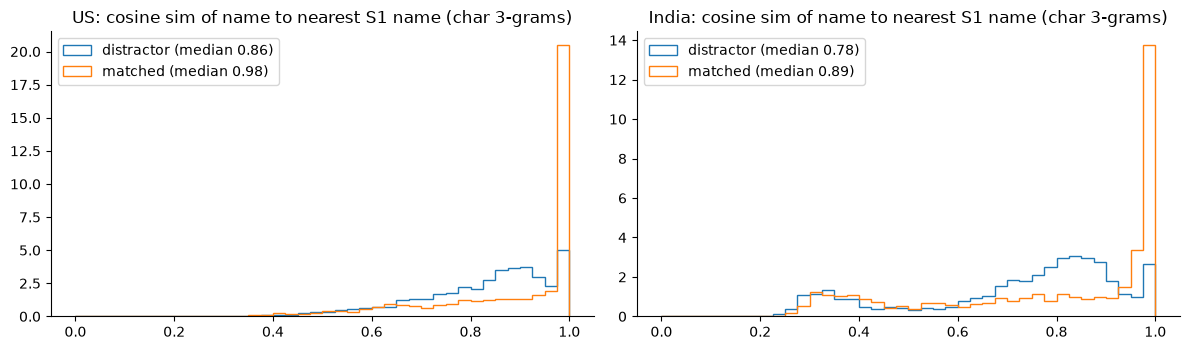

In [39]:
# nearest-name look-alike for a sample of distractors: how close do they get to *some* S1 entity?
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

def nearest_s1_score(country, n=2000):
    s1c = s1[(s1["split"] == "train") & (s1["country"] == country)]
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 3), min_df=2, dtype=np.float32)
    X = vec.fit_transform(s1c["name_n"])
    nn = NearestNeighbors(n_neighbors=1, metric="cosine").fit(X)
    out = {}
    for lab, flag in (("distractor", False), ("matched", True)):
        q = s23[(s23["country"] == country) & (s23["is_matched"] == flag)].pipe(take, n, SEED)
        d, _ = nn.kneighbors(vec.transform(q["name_n"]))
        out[lab] = 1 - d[:, 0]
    return out

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, c in zip(axes, ("US", "India")):
    o = nearest_s1_score(c)
    for lab, v in o.items():
        ax.hist(v, bins=40, range=(0, 1), histtype="step", density=True, label=f"{lab} (median {np.median(v):.2f})")
    ax.set_title(f"{c}: cosine sim of name to nearest S1 name (char 3-grams)"); ax.legend()
plt.tight_layout(); plt.show()

## 10. Blocking feasibility

In [40]:
# document frequency of every name token across train S2+S3, per country
t0 = time.time()
df_lookup = {}
for c in s23_tr["country"].cat.categories:
    names = s23_tr.loc[s23_tr["country"] == c, "name_n"]
    if len(names):
        df_lookup[c] = names.str.split(" ").explode().value_counts().to_dict()
print(f"token DF tables: {sum(map(len, df_lookup.values())):,} (country, token) keys in {time.time() - t0:.1f}s")
mem("after §10 token DF")

token DF tables: 1,482,751 (country, token) keys in 9.7s
[mem] peak 22.0 GB after §10 token DF


In [41]:
def blocking_signals(df):
    out = []
    for r in df.itertuples():
        a, b = set(r.name_n.split()), set(r.name_n_m.split())
        shared = a & b
        core = shared - LEGAL
        na = set(num_re.findall(r.addr_n)); nb = set(num_re.findall(r.addr_n_m))
        d = df_lookup.get(str(r.country), {})
        out.append({
            "shares any name token": bool(shared),
            "shares core name token": bool(core),
            "shares first token": r.name_n.split(" ")[0] == r.name_n_m.split(" ")[0],
            "shares address number": bool(na & nb),
            "core token OR address number": bool(core) or bool(na & nb),
            "rarest shared core token DF": min((d.get(t, 0) for t in core), default=np.nan),
        })
    return pd.DataFrame(out, index=df.index)

bs_pos = blocking_signals(pos.pipe(take, 100_000, SEED))
bs_neg = blocking_signals(rneg.pipe(take, 100_000, SEED))
flags = [c for c in bs_pos.columns if "DF" not in c]
pd.DataFrame({"recall on true pairs": bs_pos[flags].mean(), "rate on random negatives": bs_neg[flags].mean()}) \
  .style.format("{:.2%}")

,recall on true pairs,rate on random negatives
shares any name token,90.45%,18.67%
shares core name token,86.60%,1.10%
shares first token,74.05%,0.10%
shares address number,80.17%,2.70%
core token OR address number,97.87%,3.77%


In [42]:
# per-country recall of the best simple key, and the size of the blocks it would imply
bs_pos["country"] = pos.loc[bs_pos.index, "country"].astype(str)
display(bs_pos.groupby("country")[flags].mean().style.format("{:.1%}"))
q = bs_pos["rarest shared core token DF"].dropna()
print("DF of the rarest shared core name token (i.e. block size if you block on that token):")
print(q.quantile([0.5, 0.75, 0.9, 0.95, 0.99]).astype(int).to_string())

,shares any name token,shares core name token,shares first token,shares address number,core token OR address number
country,,,,,
India,87.8%,78.9%,63.0%,83.0%,97.0%
US,92.2%,91.7%,81.4%,78.3%,98.4%


DF of the rarest shared core name token (i.e. block size if you block on that token):
0.50      898
0.75     8882
0.90    21145
0.95    25359
0.99    45581


In [43]:
# true pairs that NO simple key catches — what are they?
missed = bs_pos[~bs_pos["core token OR address number"]].index
pos.loc[missed].pipe(take, min(15, len(missed)), 1)[["country", "name", "name_m", "address", "address_m"]]

,country,name,name_m,address,address_m
138658,US,Select Continental Scientific LLC,selectc0ntinentalscientific.com,"7400 Willesden Lane, Charlotte, NC","Willesden Ln, Charlotte CITY, North Carolina"
157695,India,Aditin Entech Limited,AE,"Moshiara, West Bengal, Indpur, C/O Nirmal Kumar Ganguli, Bankura","C/O Nirmal Kumar Ganguli, Moshiara, Indpur, Bankura, West Bengal"
34272,India,Gujarat Solutions Private Limited,গুজরাট সলিউশনস প্রাইভেট লিমিটেড,"Village Adarsha Nagar P O Panchpata(Garia), Sonarpur, Kolkata, Howrah, West Bengal","BLOCK B-822 VILLAGE ADARSHA NAGAR P O PANCHPATA(GARIA), SONARPUR, HOWRAH, KOLKATA, West Bengal"
227003,India,Hari Infra Limited,ହରି ଇନଫ୍ରା ଲିମିଟେଡ୍,"C/O- Saroj Kumar Sahoo, At-Mirapatana Po- Kendrapara, Kendrapara, Orissa","KENDRAPARA, DOOR NO 328 C/O- SAROJ KUMAR SAHOO, AT-MIRAPATANA PO- KENDRAPARA, Orissa, KENDRAPARA"
233450,India,Hotel Healthcare Private Limited,होटल हेल्थकेयर प्राइवेट लिमिटेड,"Pushpraj Nagar Colony Rasulpur, Varanasi, Uttar Pradesh","VARANASI, Uttar Pradesh, PUSHPRAJ NAGAR COLONY RASULPUR"
171553,India,Future Developers Private Limited,फ्यूचर डेवलपर्स प्राइवेट लिमिटेड,"403 K Diamond Gardension Trombay Rd Chembur, Mumbai, Maharashtra","00403 K Diamond Gardension Trombay Rd Chembur, Mumbai, MH"
48835,US,Hilliard Ellington Inc,hilliardellington.com,"KY, 293 Shacks Branch Road, Jackson","93 SHACKS BRANCH ROAD, JACKSON, KY"
222494,India,Future Jain Consultants Private Limited,Futurejainconsultants.Com,"Badnor Road Kanya Shala Ke Pass Bhim, Tehsil Bhim, Rajsamand, Rajasthan","Badnor Road Kanya Shala Ke Pass Bhim, Tehsil Bhim, Bhim Dist Rajsamand, राजस्थान"
239976,India,Ace Infotech Private Limited,एस इंफोटेक प्राइवेट लिमिटेड,"C/O Deepak Rajaram Kamble Vidya Vihar Building Kalyan, Kalyan, Thane, Maharashtra","#318 C/O DEEPAK RAJARAM KAMBLE VIDYA VIHAR BUILDING KALYAN, KALYAN, THANE, Maharashtra"
240937,US,"Louisa H. Wilkerson, D.D.S.",louisahwilkerson.com,"1501 Tenth Street, Frederick, MD","FREDERICK, MD, 150 TENTH STREET"


In [44]:
# largest blocks: most frequent core tokens (these must be down-weighted / capped)
for c, d in df_lookup.items():
    top = sorted(((v, k) for k, v in d.items() if k not in LEGAL), reverse=True)[:25]
    print(c, [(k, v) for v, k in top])

India [('praivet', 367078), ('india', 237409), ('com', 146715), ('center', 132943), ('industries', 83424), ('ventures', 74828), ('brothers', 73955), ('solutions', 72566), ('trading', 71301), ('exports', 64410), ('li', 63371), ('pra', 63166), ('smt', 54767), ('partners', 53577), ('technologies', 53536), ('holdings', 53104), ('l', 50443), ('infratech', 47494), ('overseas', 47101), ('traders', 45248), ('service', 44328), ('limitet', 44199), ('praibhet', 42901), ('elelpi', 41671), ('foundation', 40337)]


US [('l', 298194), ('center', 297581), ('partners', 273153), ('com', 267384), ('c', 232832), ('care', 163121), ('holdings', 146317), ('associates', 133680), ('d', 119767), ('health', 103716), ('a', 92271), ('p', 91916), ('clinic', 79093), ('service', 78360), ('pediatric', 68755), ('medicine', 67308), ('dental', 54536), ('family', 50370), ('summit', 49014), ('highland', 48883), ('valley', 48652), ('coastal', 46984), ('harbor', 46897), ('metro', 46615), ('global', 45581)]


## 11. Train vs test shift, and the unseen France slice

In [45]:
recs["devanagari"] = recs["name"].str.contains(SCRIPTS["Devanagari"])
recs["accents"] = recs["name"].str.contains(r"[À-ÖØ-öø-ÿ]")
shift = recs.groupby(["country", "source", "split"], observed=True).agg(
    rows=("entity_id", "size"), no_addr=("no_addr", "mean"), devanagari=("devanagari", "mean"),
    accents=("accents", "mean"), domain=("is_domain", "mean"), name_tokens=("name_tokens", "mean"),
    addr_parts=("addr_parts", "mean"))
shift.style.format({"rows": "{:,}", "no_addr": "{:.2%}", "devanagari": "{:.2%}", "accents": "{:.2%}",
                    "domain": "{:.2%}", "name_tokens": "{:.2f}", "addr_parts": "{:.2f}"})

In [46]:
fr = recs.loc[recs["country"] == "France", ["source", "entity_id", "name", "address", "name_n", "addr_n", "accents"]]
fr.groupby("source", observed=True).sample(6, random_state=4)[["source", "entity_id", "name", "address"]]

,source,entity_id,name,address
13231037,S1,S1-817201932,Terre Culture SAS,"59 Rue Léon Blum, Nouvelle-Aquitaine, Bordeaux"
12621034,S1,S1-642071411,GXT Anciens,"21 Avenue Frédéric Sauvage, Tourcoing, Hauts-de-France"
13447970,S1,S1-771393435,Terres (France) Patrimoine SASU,"16 Rue Jeanne d'Arc, Calais, Hauts-de-France"
12839898,S1,S1-691733585,Boutique Compagnie SARL,"49 Avenue du Général Leclerc, Pessac, Nouvelle-Aquitaine"
13435399,S1,S1-220441312,Nahalat Sportive SAS,"8 Rue Brascassat, Bordeaux, Nouvelle-Aquitaine"
12795633,S1,S1-28519154,Tourcoing Sante SAS,"33 Rue du Docteur Louis Delegrange, Tourcoing, Hauts-de-France"
16782150,S2,S2-520664221,Roubaix Maison S.A.R.L.,"13 RUE GUIZOT, ROUBAIX"
15116685,S2,S2-6557541,DESCENDANTS & CIE SASU,"4 RUE DE LORRAINE, MAISON DES ASSOCIATIONS, PORNIC, Loire-Atlantique"
17516325,S2,S2-870996068,institut de la antoine,"6 R DE LA MITTCRIE, LILLE, Nord"
17087333,S2,S2-190590604,@ruedart,"NANTES, 23 T CHEMIN DES GARNIERS, Pays de la Loire"


In [47]:
for src in ("S1", "S2", "S3"):
    d = fr.loc[fr["source"] == src, "name_n"].str.split(" ").explode().value_counts()
    print(f"{src} name tokens:", d.head(35).index.tolist())
print()
for src in ("S1", "S2", "S3"):
    d = fr.loc[fr["source"] == src, "addr_n"].str.split(" ").explode()
    d = d[~d.str.fullmatch(r"\d+")].value_counts()
    print(f"{src} address tokens:", d.head(35).index.tolist())

S1 name tokens: ['sarl', 'sas', 'club', 'france', 'de', 'eurl', 'ecole', 'amicale', 'comite', 'sa', 'maison', 'du', 'sasu', 'centre', 'union', 'sci', 'sportive', 'des', 'college', 'amis', 'primaire', 'federation', 'pharmacie', 'cie', 'sante', 'saint', 'etablissements', 'la', 'parents', 'ets', 'bordeaux', 'freres', 'lycee', 'fils', 'maternelle']


S2 name tokens: ['sarl', 'sas', 'france', 'club', 's', 'de', 'eurl', 'ecole', 'sa', 'amicale', 'comite', 'sasu', 'a', 'sci', 'groupe', 'du', 'maison', 'com', 'developpement', 'centre', 'fils', 'union', 'des', 'sportive', 'cie', 'international', 'distribution', 'holding', 'participations', 'federation', 'amis', 'college', 'primaire', 'la', 'pharmacie']


S3 name tokens: ['sarl', 'sas', 'france', 'club', 's', 'de', 'eurl', 'ecole', 'amicale', 'sa', 'a', 'comite', 'sasu', 'sci', 'groupe', 'du', 'maison', 'com', 'centre', 'developpement', 'fils', 'union', 'sportive', 'des', 'cie', 'participations', 'international', 'distribution', 'holding', 'amis', 'federation', 'college', 'primaire', 'pharmacie', 'la']



S1 address tokens: ['de', 'rue', 'la', 'france', 'hauts', 'nouvelle', 'aquitaine', 'loire', 'pays', 'bordeaux', 'nantes', 'lille', 'du', 'des', 'avenue', 'saint', 'tourcoing', 'dunkerque', 'roubaix', 'calais', 'nazaire', 'pessac', 'allee', 'buch', 'teste', 'bis', 'merignac', 'cap', 'ferret', 'boulevard', 'lege', 'pornic', 'l', 'd', 'jean']


S2 address tokens: ['de', 'rue', 'r', 'la', 'loire', 'bordeaux', 'nantes', 'lille', 'du', 'france', 'hauts', 'des', 'nord', 'gironde', 'nouvelle', 'aquitaine', 'atlantique', 'pays', 'saint', 'calais', 'tourcoing', 'no', 'dunkerque', 'avenue', 'roubaix', 'nazaire', 'pessac', 'buch', 'teste', 'av', 'merignac', 'cap', 'ferret', 'ndeg', '']


S3 address tokens: ['de', 'rue', 'la', 'r', 'loire', 'bordeaux', 'nantes', 'france', 'hauts', 'lille', 'du', 'des', 'nouvelle', 'aquitaine', 'nord', 'gironde', 'pays', 'atlantique', 'saint', 'calais', 'tourcoing', 'avenue', 'dunkerque', 'no', 'roubaix', 'nazaire', 'pessac', 'buch', 'teste', 'merignac', 'av', 'cap', 'ferret', 'ndeg', 'lege']


In [48]:
# French address structure: postal codes, street types, region as last component
fa = fr["address"].fillna("")
fp = pd.DataFrame({
    "5-digit postal code": fa.str.contains(r"\b\d{5}\b"),
    "rue/r.": fa.str.contains(r"(?i)\b(rue|r\.)\s"),
    "avenue/av": fa.str.contains(r"(?i)\b(avenue|av\.?)\s"),
    "boulevard/bd": fa.str.contains(r"(?i)\b(boulevard|bd|bld)\b"),
    "bis/ter": fa.str.contains(r"(?i)\b\d+\s*(bis|ter)\b"),
    "starts with region": fa.str.match(r"(?i)^\s*(Île|Ile|Nouvelle|Hauts|Grand|Auvergne|Occitanie|Provence|Bretagne|Normandie|Pays|Centre|Bourgogne|Corse)"),
})
display(fp.groupby(fr["source"], observed=True).mean().style.format("{:.1%}"))
for src in ("S1", "S2", "S3"):
    print(src, last_part(fr.loc[fr["source"] == src, "address"]).value_counts().head(15).to_dict())

/tmp/ipykernel_94/3055062883.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "rue/r.": fa.str.contains(r"(?i)\b(rue|r\.)\s"),


/tmp/ipykernel_94/3055062883.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "avenue/av": fa.str.contains(r"(?i)\b(avenue|av\.?)\s"),


/tmp/ipykernel_94/3055062883.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "boulevard/bd": fa.str.contains(r"(?i)\b(boulevard|bd|bld)\b"),


/tmp/ipykernel_94/3055062883.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "bis/ter": fa.str.contains(r"(?i)\b\d+\s*(bis|ter)\b"),


,5-digit postal code,rue/r.,avenue/av,boulevard/bd,bis/ter,starts with region
source,,,,,,
S1,0.4%,65.7%,12.8%,4.3%,5.0%,6.6%
S2,0.5%,50.9%,10.4%,3.6%,3.8%,2.1%
S3,0.5%,51.5%,10.5%,3.6%,3.8%,2.3%


S1 {'Hauts-de-France': 87960, 'Nouvelle-Aquitaine': 73819, 'Pays de la Loire': 62901, 'Bordeaux': 2870, 'Nantes': 2441, 'Lille': 2211, 'Tourcoing': 1221, 'Dunkerque': 1110, 'Calais': 1057, 'Roubaix': 1050, 'Saint-Nazaire': 868, 'Pessac': 812, 'La Teste-de-Buch': 778, 'Mérignac': 691, 'Lège-Cap-Ferret': 550}


S2 {'Hauts-de-France': 76368, 'Gironde': 65047, 'Nord': 64801, 'Nouvelle-Aquitaine': 64246, 'Loire-Atlantique': 54689, 'Pays de la Loire': 54500, 'BORDEAUX': 34618, 'NANTES': 30485, 'LILLE': 27832, '': 21539, 'TOURCOING': 14620, 'DUNKERQUE': 13672, 'ROUBAIX': 13115, 'CALAIS': 12628, 'Pas-de-Calais': 11974}


S3 {'Hauts-de-France': 85734, 'Nouvelle-Aquitaine': 71925, 'Nord': 65648, 'Gironde': 65344, 'Pays de la Loire': 61870, 'Loire-Atlantique': 55324, 'Bordeaux': 38951, 'Nantes': 34117, 'Lille': 31011, '': 21542, 'Tourcoing': 16277, 'Dunkerque': 15656, 'Roubaix': 14879, 'Calais': 14283, 'Pas-de-Calais': 12158}


In [49]:
# does the same noise process (junk prefixes, legal-form swaps) seem to apply to France? quick analogue of §7
fr_first = first[fr.index].fillna("<none>")
pd.crosstab(fr["source"], fr_first, normalize="index").drop(columns="<none>", errors="ignore") \
  .pipe(lambda d: d.loc[:, d.max().sort_values(ascending=False).index[:12]]).style.format("{:.2%}")

prefix,&,dr,mr,<<,+,mrs,sri,>>,"""""",shri,[&]
source,,,,,,,,,,,
S1,0.00%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
S2,0.02%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
S3,0.02%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


In [50]:
# how well does our (transliteration-based) normaliser treat French? accented vs unaccented variants collapse?
ex = fr[fr["accents"]].pipe(take, 8, 9)
ex[["source", "name", "name_n", "address", "addr_n"]]

,source,name,name_n,address,addr_n
13991972,S1,Comité du Socio,comite du socio,"20 Rue du Prinquiau, Nantes, Pays de la Loire",20 rue du prinquiau nantes pays de la loire
12883143,S1,Collège Residents,college residents,"62 bis Rue de Vic, Calais, Hauts-de-France",62 bis rue de vic calais hauts de france
20967375,S3,Maison de Santé dê la Pierre Groupe,maison de sante de la pierre groupe,"40 - Rue Dadé, La Teste-de-buch, Nouvelle-Aquitaine",40 rue dade la teste de buch nouvelle aquitaine
21040748,S3,Union du Quartier Développement,union du quartier developpement,"18 Avenue De L’observatoire Pyla, Gironde, La Teste-de-buch",18 avenue de l observatoire pyla gironde la teste de buch
18239369,S2,Team Jëunes SAS,team jeunes sas,"15BIS RUE LAMOTHE PICHON, BORDEAUX",15bis rue lamothe pichon bordeaux
15298251,S2,Établissements Nationale Sarl,etablissements nationale sarl,"79 R. ASSIA DJEBAR, LILLE, Nord",79 r assia djebar lille nord
17176001,S2,Club de Çaestre,club de caestre,"BOULEVARD JEAN-JACQUES BSC, BORDEAUX, Gironde",boulevard jean jacques bsc bordeaux gironde
21829822,S3,Maelys Collège Sci,maelys college sci,"67 Rue Raspail, Lille, Hauts-de-France",67 rue raspail lille hauts de france


## 12. Leakage sanity checks (IDs and file order)

In [51]:
# do entity-id numbers or file row positions carry match information? (they should not; we will not use them)
pos_in_file = {}
for src in ("S1", "S2", "S3"):
    ids = recs.loc[(recs["split"] == "train") & (recs["source"] == src), "entity_id"]
    pos_in_file.update(dict(zip(ids, np.arange(len(ids)) / len(ids))))

smp = pairs.pipe(take, 200_000, SEED)
a_num = smp["s1"].str.slice(3).astype(int); b_num = smp["m"].str.slice(3).astype(int)
a_pos = smp["s1"].map(pos_in_file); b_pos = smp["m"].map(pos_in_file)
print(f"Spearman(id number S1, id number match):   {a_num.corr(b_num, method='spearman'):+.4f}")
print(f"Spearman(file position S1, file position): {a_pos.corr(b_pos, method='spearman'):+.4f}")
gt_order = gt["s1"].map(pos_in_file)
print(f"Spearman(GT row order, S1 file order):     {pd.Series(np.arange(len(gt))).corr(gt_order, method='spearman'):+.4f}")

Spearman(id number S1, id number match):   +0.0046
Spearman(file position S1, file position): +0.0017


Spearman(GT row order, S1 file order):     +0.0003


## 13. Verdict

**In one line:** this is a clean, synthetic, generator-made dataset. Names and addresses are each noisy enough that
neither is sufficient alone, but *together* — especially with address numbers — they separate matches well. The real
difficulty is precision against deliberate look-alikes, cross-script Indian names, and a test set with roughly twice
the distractor load of train plus an unseen country.

### What the data is

- **Clean and consistent structure (§1, §5, §12).** No duplicate IDs, every S1 entity in the ground truth exactly once,
  every matched ID exists, and **each S2/S3 record belongs to at most one S1 entity** — matching is an assignment
  problem, not free-form linking. IDs and file order carry no signal (Spearman ≈ 0), so there is no leakage to worry about.
- **It is synthetic, from one noise generator.** India and US have *identical* ground-truth statistics (5.6% singletons,
  mean 3.46 matches, max 11), junk prefixes appear at identical rates across options (`sri`, `m/s`, `shri`, `mr`, `dr`
  each 0.5–0.6%), and the same corruptions recur (letter swaps `C0nstruction`, `5orensen`; `Saint` for `Street`;
  numbers padded to `0227`). The noise menu is finite and learnable from train — and the same generator produced France.
- **Each source has a "house style" (§3, §8).** S1 is clean title case with full street types and state abbreviations
  (US) / full state names (India). S2 is ~90% ALL-CAPS for US addresses, abbreviates street types (`ST`, `RD`, `DR`; S3 does too).
  S3 spells out US states (`Pennsylvania`) but abbreviates Indian ones (`MH`, `DL`, `TN`), and both S2 and S3
  often write Indian states in native script (`महाराष्ट्र`, `ಕರ್ನಾಟಕ`). Postal codes are effectively absent everywhere (<1%) — they are not a usable blocking key.

### Ground truth

- **Almost everything matches.** Only 5.6% of S1 entities are singletons; the median entity has 3 matches, usually from
  both sources (80.5% have S2 *and* S3 matches; over half have ≥2 records in a single source).
- **~26% of S2/S3 records are distractors**, and they are *look-alikes*, not noise: their names sit at a median char-3-gram
  cosine of 0.86 (US) / 0.78 (India) to the nearest S1 name (§9). Only 4–6% share an exact normalised name with an S1
  entity, versus 20–35% of true matches.
- **Test is harder than train.** Test has ~5.7 S2+S3 records per S1 entity versus 4.7 in train. If match counts stay
  at ~3.46 per entity, that is **~2.1–2.4 distractors per entity in test versus 1.2 in train** — roughly double the
  false-merge opportunities. Thresholds tuned on train will be optimistic; validate with extra injected distractors.
- A missing address is a strong *prior* for being a real match: 97.7% of empty-address S2/S3 records are matched.

### How matches differ (§6–§8)

- **Names:** only 4.7% of true pairs are byte-identical, 25.8% after simple normalisation. The largest differences are
  legal forms/filler words (20–27%), extra or missing core words (12–17%), punctuation/accents, typos, word order,
  domain-style names (`southernnoble.com`, ~4%) and heavy rewrites (~10%, including acronyms like `AE`, `AC`).
- **Indian names cross scripts:** 18% of Indian positive pairs have a non-Latin S2/S3 name (Devanagari ~13% of S2; also
  Bengali, Gujarati, Tamil, Telugu, Kannada, Odia). Generic transliteration is phonetically poor
  (`प्राइवेट` → `praivet`, `एलएलपी` → `elelpi`), so these pairs share almost no tokens with S1.
- **Addresses:** only 8.3% identical after normalisation, but **address numbers are the strongest single signal**:
  91.6% of true pairs that both have numbers share one, versus ~3% for random *and* name-similar negatives. Addresses
  also drop components, reorder them, swap in neighbouring or alias cities (`Bangalore`/`Bengaluru`, `Bombay`,
  `Calcutta`, a township vs its city) and render states in 3 forms (full, abbreviation, native script).
- **Separability:** median name token-set score is 100 for positives, 60 for name-similar negatives, 34 for random;
  address token-set 94 vs 37 vs 37. A naive two-threshold rule already reaches ~98% precision at ~85% recall on a
  *balanced* positive/hard-negative sample — so a learned model on rich pair features should do well, as long as it
  is calibrated for the far more imbalanced real candidate set.

### The precision risk (§9)

- **29–44% of S1 entities share their normalised name with another S1 entity**, in groups of up to 253
  (`Primary Care Group`, `Dental Group`, `Azad Clinic`, `607 Fifth St Owners Corp LLC`). For these, the name carries
  no identity at all and the address (numbers, street, city) must decide. Name-only matching is guaranteed to merge
  distinct businesses — exactly what F0.5 punishes hardest.
- Because each S2/S3 record belongs to one S1 entity, **assigning each candidate record only to its best-scoring S1
  entity** (then thresholding) removes a whole class of false merges for free.

### Blocking (§10)

- **"Shares a core (non-legal) name token OR an address number" reaches 97.9% recall** (US 98.4%, India 97.0%) while
  touching only 3.8% of random pairs. Name tokens alone: 86.6%; address numbers alone: 80.2%.
- Token blocks are **very unbalanced**: the rarest shared core token has a median document frequency of ~900 but a
  90th percentile of ~21k, and generic tokens (`center`, `partners`, `care`, `praivet`, `india`, `com`, single letters)
  hit 100k–370k records. Raw token blocking is infeasible — use TF-IDF-weighted top-k neighbours, or cap/skip
  high-frequency tokens, per country.
- **The ~2% that simple keys miss** are almost entirely: non-Latin Indian names, domain-style names with no spaces
  (`selectc0ntinentalscientific.com`), acronyms (`AE`, `AC`), and addresses whose numbers were dropped or corrupted.
  These need character n-grams over space-stripped names, better Indic transliteration, and possibly multilingual
  embeddings.

### France (§11) — unseen in train

- It comes from the **same generator**: the same source "house styles" (S2 upper-case street parts, `R.`/`AV` street
  abbreviations, domain names at ~3.5%, empty addresses at ~3%), no postal codes.
- New vocabulary: legal forms `SARL`, `SAS`, `SASU`, `EURL`, `SCI`, `SA`, `& Fils`, `Cie`; heavy stopwords (`de`, `la`,
  `du`, `des`); natural accents on ~16–28% of records (the normaliser already folds these correctly). France has
  essentially **no junk name prefixes** (0.02% vs ~0.6% elsewhere).
- **Addresses mix administrative levels:** S1 ends in regions (`Hauts-de-France`, `Nouvelle-Aquitaine`), while S2/S3
  often end in departments (`Nord`, `Gironde`, `Loire-Atlantique`) or upper-case cities. Region vs department must not
  count as a mismatch.
- The data covers only a handful of cities (Bordeaux, Nantes, Lille, Tourcoing, Dunkerque, Calais, Roubaix, …), and
  generic names (`Club`, `Ecole`, `Amicale`, `Comité`) collide heavily — expect the name-collision problem to be
  at least as bad as in the US.

### What this means for the pipeline

1. **Normalise per field, country-agnostically:** accent folding + transliteration; legal/filler words identified
   *by frequency learned from data* (so `SARL`/`SAS` are handled for France without hand-coding US/India lists);
   street-type and state/city aliases **learned from aligned training pairs** rather than from external lookup tables
   (keeps us clear of the no-external-data rule).
2. **Indic names:** learn a token translation table from training pairs whose S2/S3 name is non-Latin
   (e.g. `praivet → private`, `elelpi → llp`), and/or use a small multilingual embedding model (GPU) for these.
3. **Blocking, per country:** union of (a) TF-IDF char-n-gram nearest neighbours on space-stripped names, (b) shared
   rare name tokens with a frequency cap, (c) shared address numbers within the same city/state. Target ≥98% recall;
   measure it in `02_blocking_analysis.ipynb`.
4. **Matcher:** LightGBM on pair features — name similarities (ratio, token-set, partial, char n-gram TF-IDF cosine,
   acronym and domain checks), address-number overlap and containment, street/city/state agreement after alias
   mapping, field-presence flags, and how common the name is (collision-group size). No country one-hot.
5. **Decision:** give each S2/S3 record to its single best S1 entity, then apply a threshold tuned for **F0.5** on a
   validation split *with extra injected distractors* to mimic test's higher distractor load. Lean strict: a missed
   link costs less than a false merge, and 5.6% of entities score 1.0 only when left empty.
6. **Resources:** the full EDA peaked at ~22 GB of RAM on Kaggle (30 GB limit). Pipeline stages should stream or
   process per country and persist intermediate candidates/features to disk.
